# 02 · Distribution fitting

Use the Kamp at Zwettl inputs to compare candidate distributions before a focused Bayesian analysis.
Restart Kernel and Run All constructs and runs every fit from raw observations through pythonnet.
API reference: `DistributionFitting/FittingAnalysisTests.cs`, `CreateTestDataFrame`,
`CreateTestFittingAnalysis`, and `Test_FittingAnalysis_WabashRiverData` in BestFit Verification.
Those methods supply the construction pattern; the data remain the original Kamp examples.

In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from time import perf_counter
import numpy as np
import pandas as pd
from IPython.display import display
from bestfit_examples.runtime import load_bestfit
from bestfit_examples.raw import load_raw
from bestfit_examples.fresh import plot_context, plots, show, record_run
runtime = load_bestfit()
print(runtime)
from System import Array, Double, DateTime
from Numerics.Data import ProbabilityOrdinates
from Numerics.Distributions import (Exponential, GammaDistribution, GeneralizedExtremeValue,
    GeneralizedLogistic, GeneralizedNormal, GeneralizedPareto, Gumbel, KappaFour,
    LnNormal, Logistic, LogNormal, LogPearsonTypeIII, Normal, PearsonTypeIII, Weibull)
from RMC.BestFit.Models import DataFrame, ExactData, ExactSeries, IntervalData, ThresholdData
from RMC.BestFit.Analyses import FittingAnalysis

{'schemaVersion': 1, 'sourceCommit': 'db5807d6e3a85606797cda79542f2d51a80a57a6', 'numericsVersion': '2.2.0.0', 'bestFitVersion': '2.0.0.0', 'targetFramework': '.NETCoreApp,Version=v10.0', 'fileHashes': {'RMC.BestFit.dll': '8714d7e4e9d738e99e45c36d5581ce759e8fd535361b7a141d9647a9a5eac8dd', 'Numerics.dll': '364d2296a6024643a8bf0f60d1eaa8f5be5511563dea0b5d572074e45c27ea48'}}


## Load the four original inputs

The four alternatives compare 1951–2001 and 1951–2005, each with and without temporal expansion.
The raw fixture contains values, years, historical bounds and provenance; it contains no fitted objects.
A perception threshold describes what would have been noticed during a period, not fabricated annual floods.

In [3]:
raw = load_raw("viglione-et-al-2013")
input_names = ["Systematic (1951-2001)", "Systematic (1951-2005)",
               "Systematic (1951-2001) + Temporal Expansion", "Systematic (1951-2005) + Temporal Expansion"]
display(pd.DataFrame(raw["inputs"][input_names[0]]["series"]["ExactSeries"]).head())
print(raw["source"])

,DateTime,Index,IsLowOutlier,Value
0,0001-01-01T00:00:00.0000000,1951,False,135
1,0001-01-01T00:00:00.0000000,1952,False,52
2,0001-01-01T00:00:00.0000000,1953,False,45
3,0001-01-01T00:00:00.0000000,1954,False,95
4,0001-01-01T00:00:00.0000000,1955,False,54


{'bytes': 14090240, 'relative_path': 'examples/4-univariate-distribution-analysis/1-univariate-analysis/1-information-expansion/viglione-et-al-2013.bestfit', 'repository_commit': '3fa55a0f75bbd583e2fb7fce42180faa376f007c', 'sha256': '6f6f984f8d0357d490ffde9d394601ae77324a0f293a84a3993afaf7e9762e86'}


## Construct BestFit inputs explicitly

`ExactData` retains the annual index. `IntervalData` carries the lower, central and upper flood estimates.
`ThresholdData.NumberAbove` counts additional exceedances not already entered explicitly.
BestFit computes nonexceedance counts and plotting positions after the observations are attached.
Replace these rows with your own observations while retaining their units and meaning.

In [4]:
frames = {}
for input_name in input_names:
    observed = raw["inputs"][input_name]
    frame = DataFrame()
    frame.ExactSeries = ExactSeries()
    for row in observed["series"]["ExactSeries"]:
        point = ExactData(DateTime.Parse(row["DateTime"]), float(row["Value"]))
        point.Index = int(row["Index"])
        point.IsLowOutlier = row.get("IsLowOutlier", "False") == "True"
        frame.ExactSeries.Add(point)
    for row in observed["series"]["IntervalSeries"]:
        frame.IntervalSeries.Add(IntervalData(int(row["Index"]), float(row["LowerValue"]),
                                             float(row["Value"]), float(row["UpperValue"])))
    for row in observed["series"]["ThresholdSeries"]:
        threshold = ThresholdData(int(row["StartIndex"]), int(row["EndIndex"]), float(row["Value"]))
        threshold.NumberAbove = int(row["NumberAbove"])
        frame.ThresholdSeries.Add(threshold)
    frame.PlottingParameter = 0.0
    assert frame.Lambda == 1.0  # Annual observations; no POT-to-annual conversion.
    frame.CalculatePlottingPositions()
    frames[input_name] = frame
display(pd.DataFrame([{"Input": name, "Exact": f.ExactSeries.Count,
                       "Intervals": f.IntervalSeries.Count, "Thresholds": f.ThresholdSeries.Count}
                      for name, f in frames.items()]))

,Input,Exact,Intervals,Thresholds
0,Systematic (1951-2001),51,0,0
1,Systematic (1951-2005),55,0,0
2,Systematic (1951-2001) + Temporal Expansion,51,3,1
3,Systematic (1951-2005) + Temporal Expansion,55,3,1


## Configure fifteen candidate distributions and execute MLE

The instances below define candidate families; their parameters will be fitted by BestFit.
`FittingAnalysis.RunAsync` uses the library's MLE and optimizer policy.
Probability ordinates retain the original example's upper-tail grid. Each iteration constructs
a distinct analysis. The execution call blocks until that fit has finished.

In [5]:
aep = [1e-6, 2e-6, 5e-6, 1e-5, 2e-5, 5e-5, .0001, .0002, .0005,
       .001, .002, .005, .01, .02, .05, .1, .2, .3, .5, .7, .8, .9, .95, .98, .99]
analyses, timings = {}, {}
for input_name, frame in frames.items():
    analysis = FittingAnalysis(frame)
    analysis.DistributionList.Clear()
    for distribution in (Exponential(), GammaDistribution(), GeneralizedExtremeValue(),
                         GeneralizedLogistic(), GeneralizedNormal(), GeneralizedPareto(),
                         Gumbel(), KappaFour(), LnNormal(), Logistic(), LogNormal(),
                         LogPearsonTypeIII(), Normal(), PearsonTypeIII(), Weibull()):
        analysis.DistributionList.Add(distribution)
    analysis.ProbabilityOrdinates = ProbabilityOrdinates(Array[Double](aep))
    assert not analysis.IsEstimated
    started = perf_counter()
    analysis.RunAsync(None).GetAwaiter().GetResult()
    timings[input_name] = perf_counter() - started
    analyses[input_name] = analysis
    record_run("Fit - " + input_name, analysis, timings[input_name], raw=raw)

Fit - Systematic (1951-2001): completed in 0.35 s. Execution alone does not establish convergence or scientific acceptance.


Fit - Systematic (1951-2005): completed in 0.20 s. Execution alone does not establish convergence or scientific acceptance.
Fit - Systematic (1951-2001) + Temporal Expansion: completed in 0.15 s. Execution alone does not establish convergence or scientific acceptance.


Fit - Systematic (1951-2005) + Temporal Expansion: completed in 0.10 s. Execution alone does not establish convergence or scientific acceptance.


## Read the results just computed

Keep unsuccessful fits and their messages visible. AIC/BIC rank candidates only within one fitting
alternative, where observations and likelihood treatment are the same. Scores are not ranked across inputs.
A favorable within-input score alone does not establish a plausible rare tail.

In [6]:
candidate_rows = []
for input_name, analysis in analyses.items():
    for fit in analysis.FittedDistributions:
        candidate_rows.append({"Input": input_name, "Distribution": str(fit.Distribution.DisplayName),
                               "Succeeded": fit.FitSucceeded, "AIC": float(fit.AIC),
                               "BIC": float(fit.BIC), "RMSE": float(fit.RMSE),
                               "Failure": str(fit.ErrorMessage)})
candidates = pd.DataFrame(candidate_rows)
display(candidates[candidates.Input == input_names[0]].sort_values("AIC", na_position="last"))
display(candidates.sort_values(["Input", "AIC"]).groupby("Input", sort=False).head(3))
failed_candidates = candidates.loc[~candidates["Succeeded"], ["Input", "Distribution", "Failure"]]
print(f"Unsuccessful candidates across all four inputs: {len(failed_candidates)}")
display(failed_candidates)

,Input,Distribution,Succeeded,AIC,BIC,RMSE,Failure
8,Systematic (1951-2001),Log-Normal (base e),True,476.865750,480.729401,4.134752,
10,Systematic (1951-2001),Log-Normal (base 10),True,476.865750,480.729402,4.134895,
5,Systematic (1951-2001),Generalized Pareto,True,477.515370,483.310847,5.562598,
13,Systematic (1951-2001),Pearson Type III,True,477.691944,483.487421,4.131025,
1,Systematic (1951-2001),Gamma,True,477.872561,481.736212,5.659434,
6,Systematic (1951-2001),Gumbel (EVI),True,478.118149,481.981801,5.945565,
11,Systematic (1951-2001),Log-Pearson Type III,True,478.796546,484.592023,4.491312,
4,Systematic (1951-2001),Generalized Normal,True,478.865191,484.660668,4.200849,
7,Systematic (1951-2001),Kappa-4,True,478.977015,486.704318,4.971882,
2,Systematic (1951-2001),Generalized Extreme Value,True,479.425110,485.220587,4.455896,


,Input,Distribution,Succeeded,AIC,BIC,RMSE,Failure
8,Systematic (1951-2001),Log-Normal (base e),True,476.865750,480.729401,4.134752,
10,Systematic (1951-2001),Log-Normal (base 10),True,476.865750,480.729402,4.134895,
5,Systematic (1951-2001),Generalized Pareto,True,477.515370,483.310847,5.562598,
40,Systematic (1951-2001) + Temporal Expansion,Log-Normal (base 10),True,508.840792,516.833696,18.902788,
38,Systematic (1951-2001) + Temporal Expansion,Log-Normal (base e),True,508.840793,516.833697,18.900169,
30,Systematic (1951-2001) + Temporal Expansion,Exponential,True,509.110727,517.103631,15.830746,
18,Systematic (1951-2005),Generalized Logistic,True,530.989242,537.011242,33.845285,
22,Systematic (1951-2005),Kappa-4,True,531.463755,539.493087,37.348757,
17,Systematic (1951-2005),Generalized Extreme Value,True,531.985769,538.007768,35.340353,
49,Systematic (1951-2005) + Temporal Expansion,Generalized Normal,True,561.339450,573.358510,18.243240,


Unsuccessful candidates across all four inputs: 0


,Input,Distribution,Failure


## Check an independent numerical expectation

For exact-only samples, Normal MLE equals the sample mean and population standard deviation.
A 0.1% relative tolerance is a conservative optimizer check on these fixed data, not a claim about
rare quantiles or historical-data likelihoods. It does not test the other families.

In [7]:
normal_checks = []
for input_name in input_names[:2]:
    values = np.array([float(point.Value) for point in frames[input_name].ExactSeries])
    fit = next(f for f in analyses[input_name].FittedDistributions if isinstance(f.Distribution, Normal))
    assert fit.FitSucceeded
    expected = np.array([values.mean(), values.std(ddof=0)])
    computed = np.array([float(fit.Distribution.Mu), float(fit.Distribution.Sigma)])
    np.testing.assert_allclose(computed, expected, rtol=1e-3, atol=1e-8)
    normal_checks.append({"Input": input_name, "Mean": computed[0], "Expected mean": expected[0],
                          "Sigma": computed[1], "Expected sigma": expected[1]})
display(pd.DataFrame(normal_checks))

,Input,Mean,Expected mean,Sigma,Expected sigma
0,Systematic (1951-2001),56.659541,56.656863,28.568695,28.569710
1,Systematic (1951-2005),63.824438,63.823636,60.813635,60.813611


## Plot fresh in-memory results

The canonical BestFit adapters receive the same `analysis` and `frame` objects above.
The density view emphasizes the body; the frequency view emphasizes the upper tail.
Q–Q axes are Data versus Model. Historical observations keep BestFit's plotting positions.

Systematic (1951-2001)


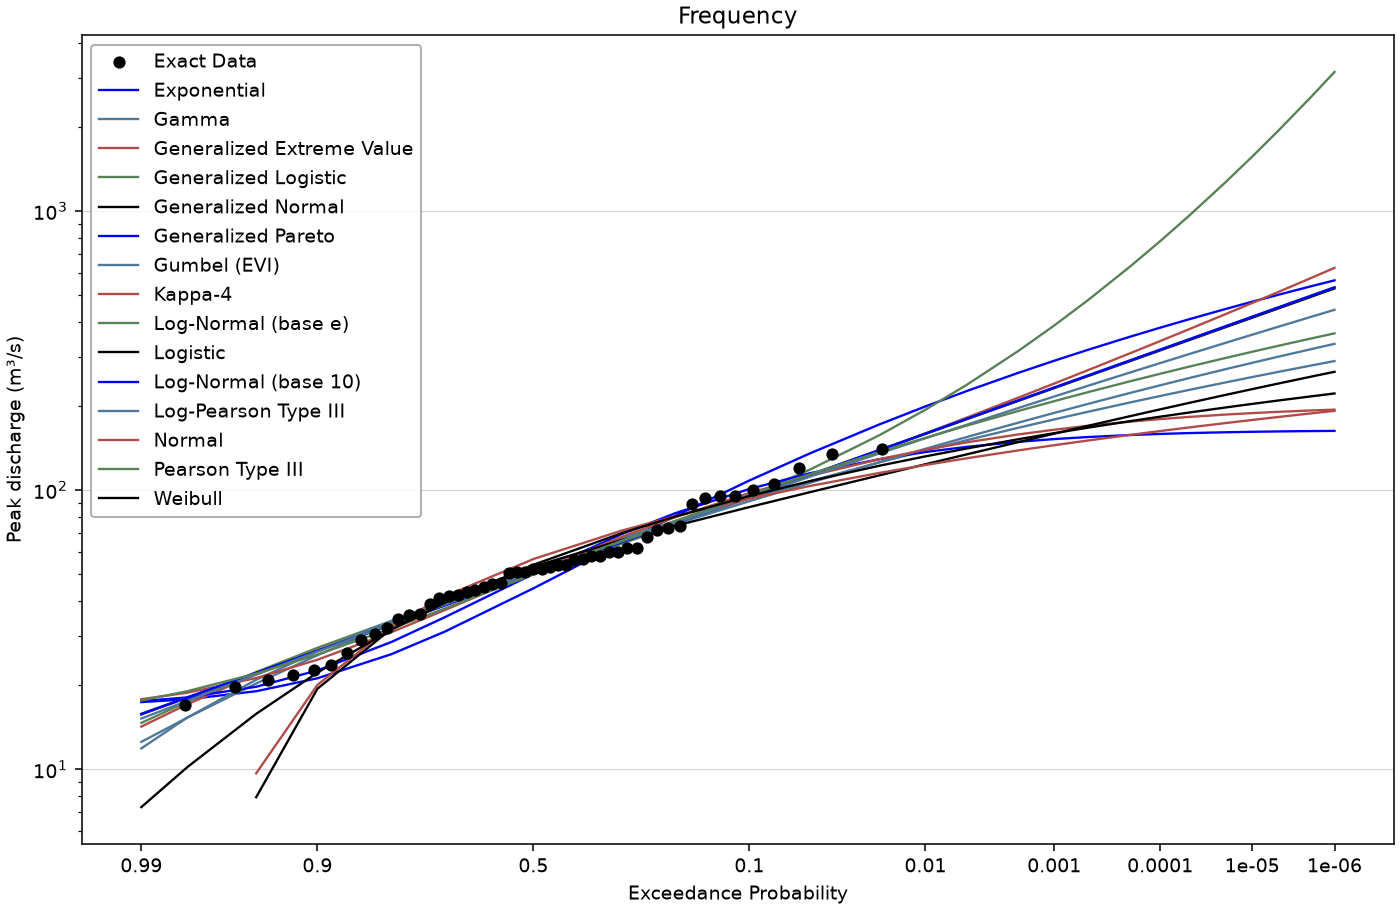

Systematic (1951-2005)


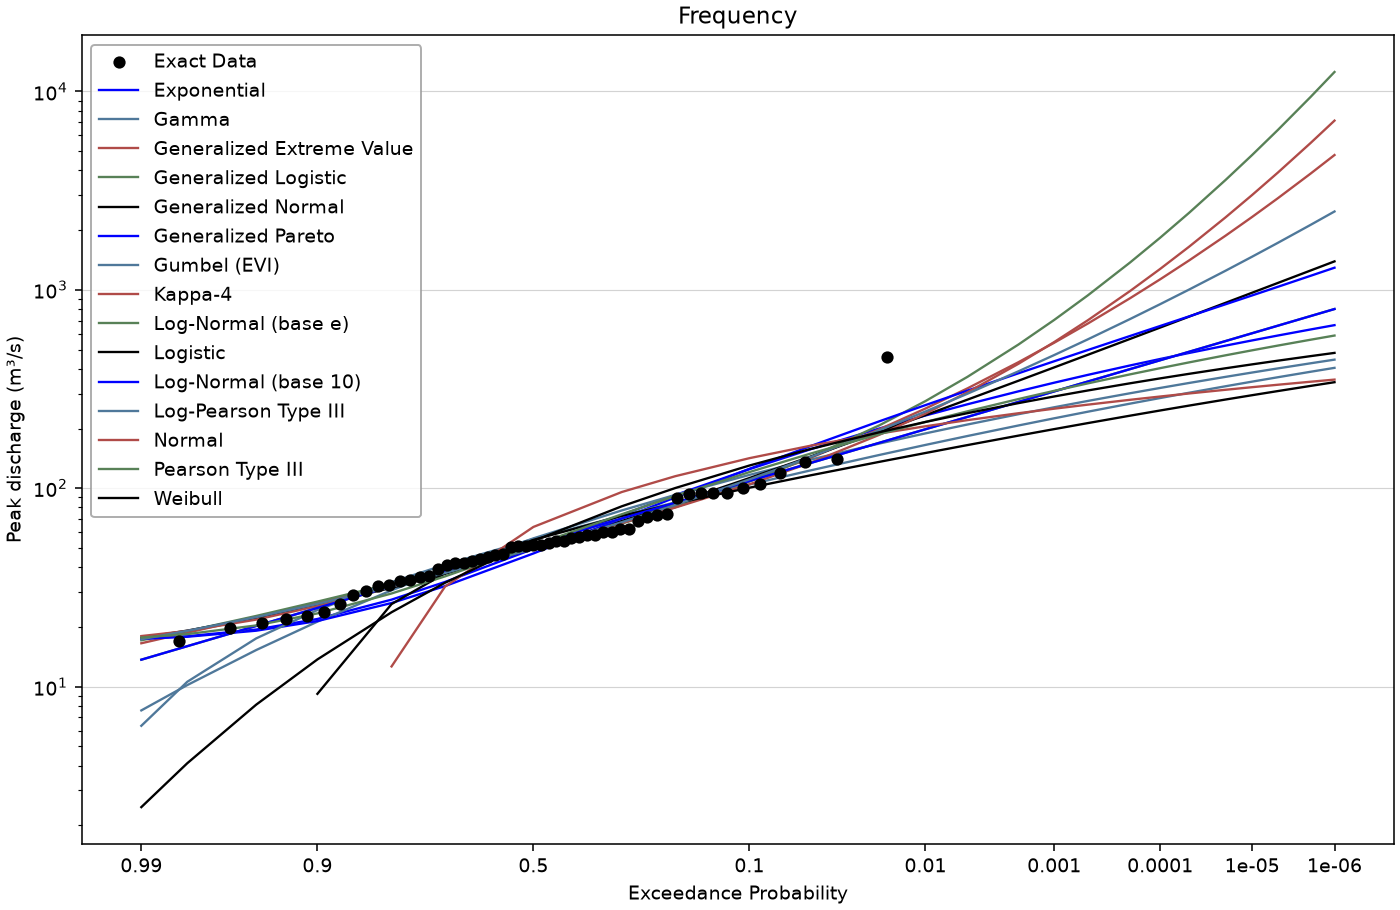

Systematic (1951-2001) + Temporal Expansion


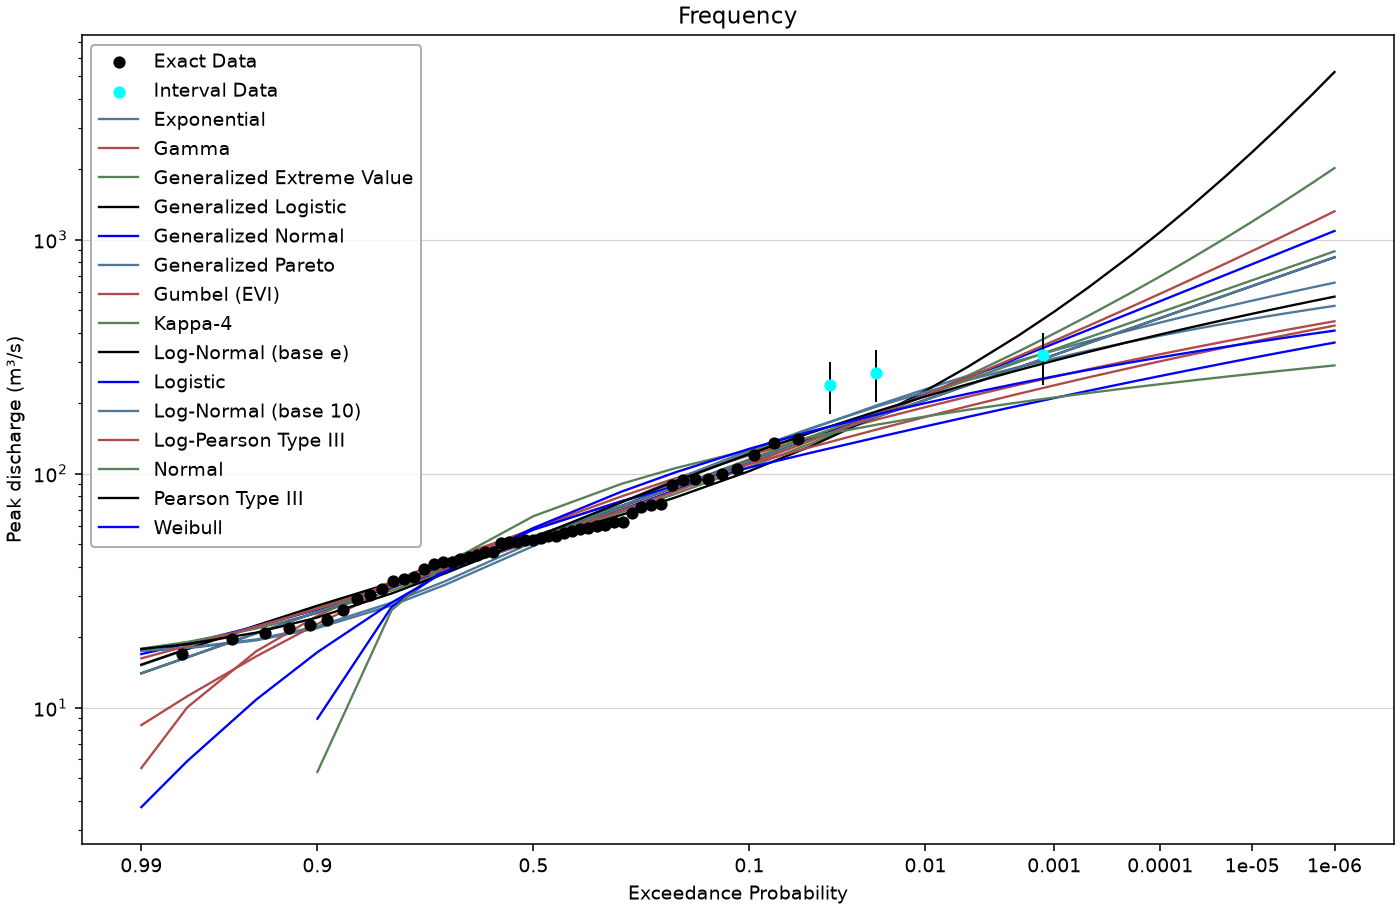

Systematic (1951-2005) + Temporal Expansion


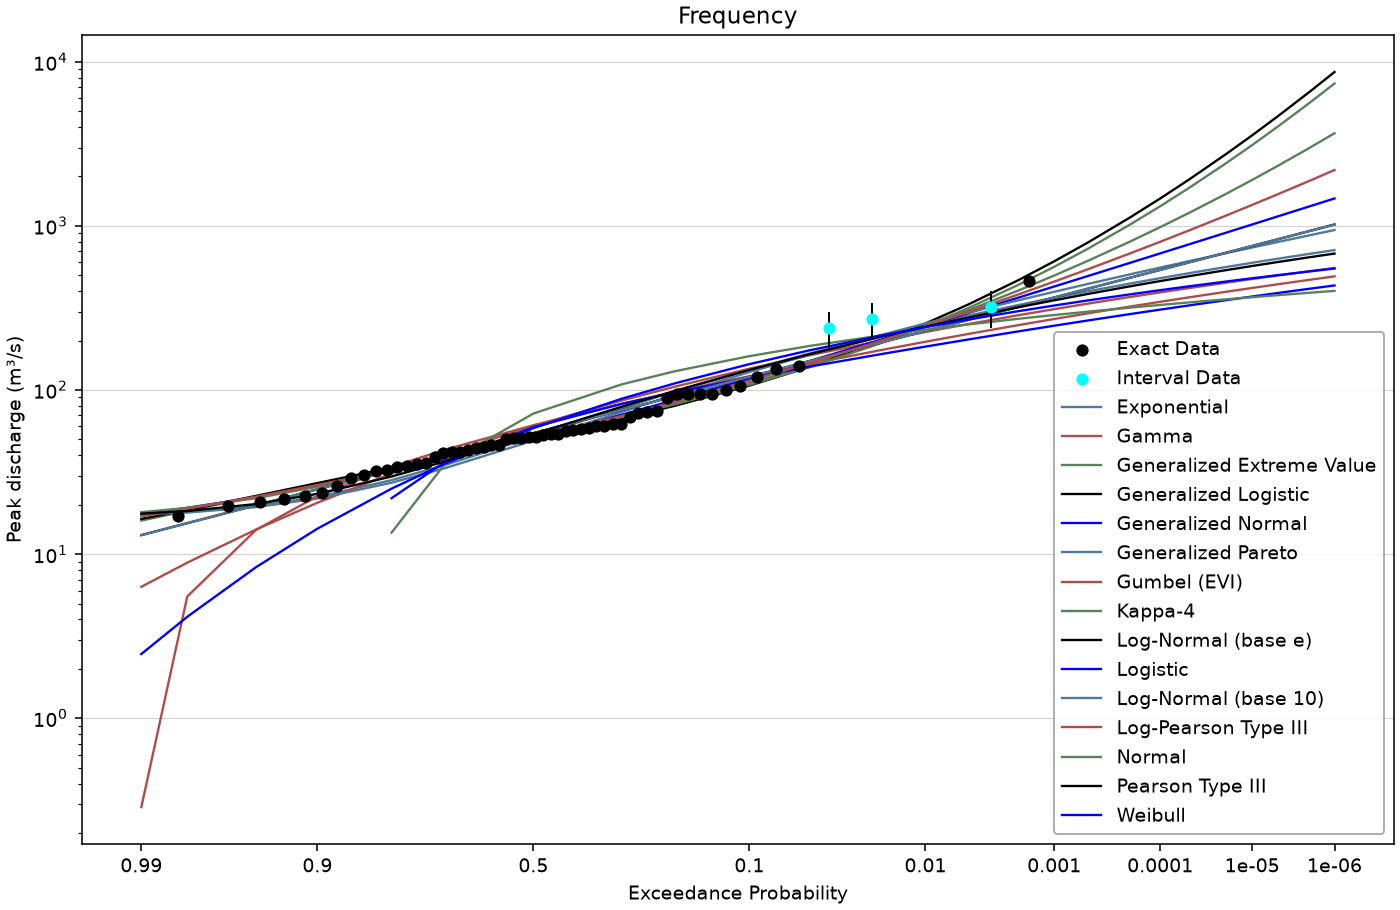

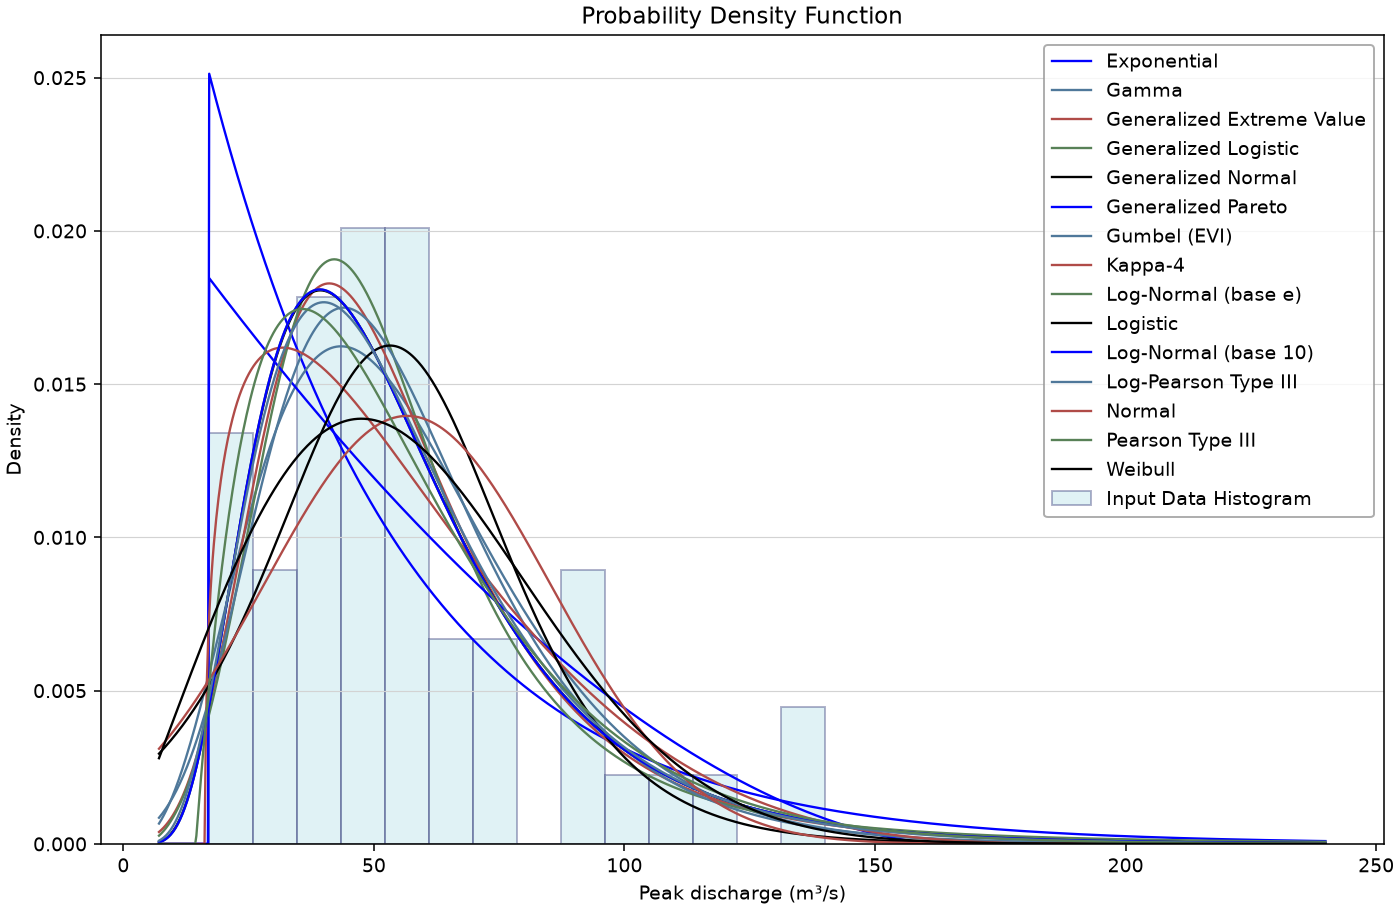

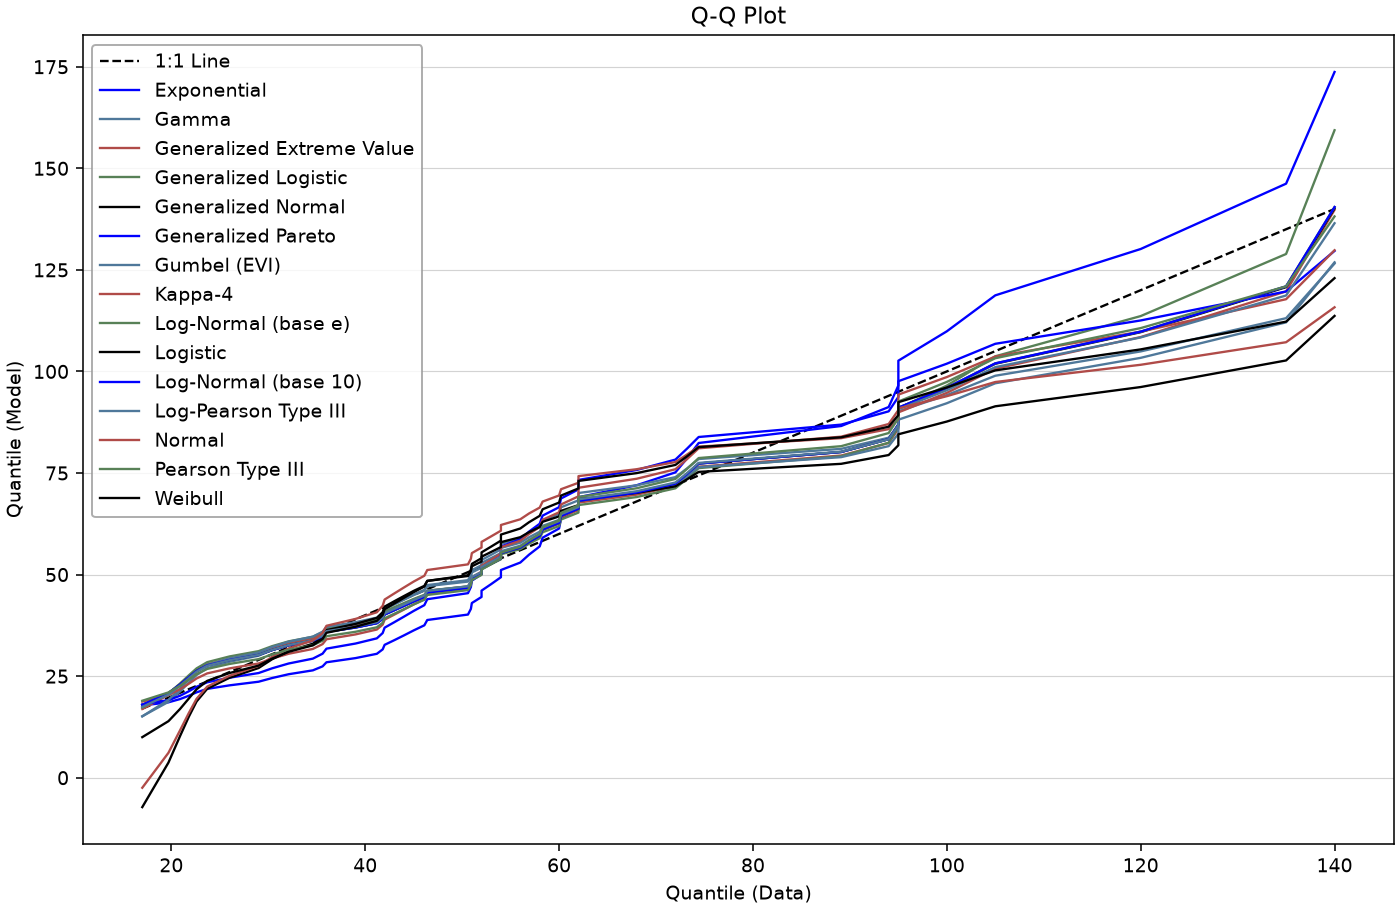

In [8]:
figure_specs = {}
for input_name in input_names:
    context = plot_context(analyses[input_name], name="Fit - " + input_name, raw=raw,
                           frame=frames[input_name], metadata=raw["inputs"][input_name]["metadata"],
                           unitLabel="Peak discharge (m³/s)")
    figure_specs[input_name] = plots(context)
    print(input_name)
    show(figure_specs[input_name]["frequency"])
show(figure_specs[input_names[0]]["pdf"])
show(figure_specs[input_names[0]]["qq"])

**Adapt this example:** replace the raw records; choose candidate families and probability ordinates;
construct a new `FittingAnalysis`, call `RunAsync`, and inspect `FittedDistributions` before plotting.
Changing periods or historical bounds changes the evidence. Notebook 03 holds the GEV family fixed
to examine those sources directly. Upstream scientific narratives remain provisional.